In [1]:
import scanpy as sc
import pandas as pd
adata = sc.read_h5ad("baseline_clustered.h5ad")

In [ ]:
#checking to see its worked

adata
adata.raw.shape

(5926, 55737)

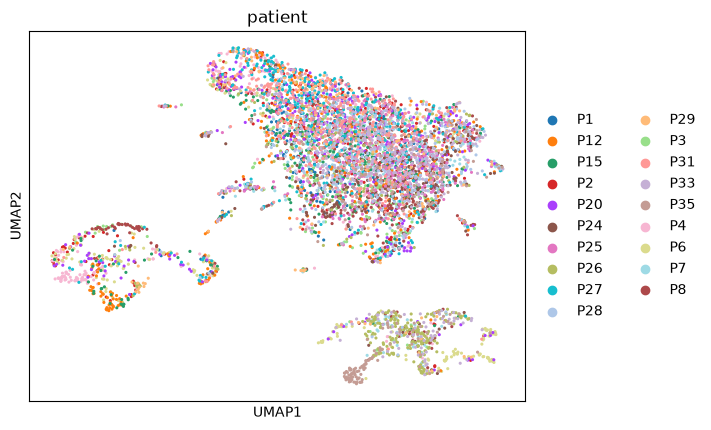

leiden_0.4
11    0.983607
10    0.331010
6     0.228438
8     0.207317
12    0.176471
4     0.166667
9     0.152174
5     0.136986
13    0.125000
0     0.122507
7     0.120482
3     0.119593
2     0.116531
1     0.115875
dtype: float64

In [ ]:
#checking if we need to batch correct.
#they mix very well so this is a good sign that we do not need to batch correct.
#if we needed to we would have seen clusters of cells that are made up of only one patient.

sc.pl.umap(adata, color="patient")

ct = pd.crosstab(adata.obs["leiden_0.4"], adata.obs["patient"], normalize="index")
ct.max(axis=1).sort_values(ascending=False)

In [ ]:
#we don't want to use Harmony (batch correction) because this would hide what is going on with cluser 11. 
#like we said before, cluster 11 is almost entirely made up of one patient. 
# If we batch correct, we would be hiding this fact.


ct = pd.crosstab(adata.obs["leiden_0.4"], adata.obs["patient"], normalize="index")
ct.max(axis=1).sort_values(ascending=False)

leiden_0.4
11    0.983607
10    0.331010
6     0.228438
8     0.207317
12    0.176471
4     0.166667
9     0.152174
5     0.136986
13    0.125000
0     0.122507
7     0.120482
3     0.119593
2     0.116531
1     0.115875
dtype: float64

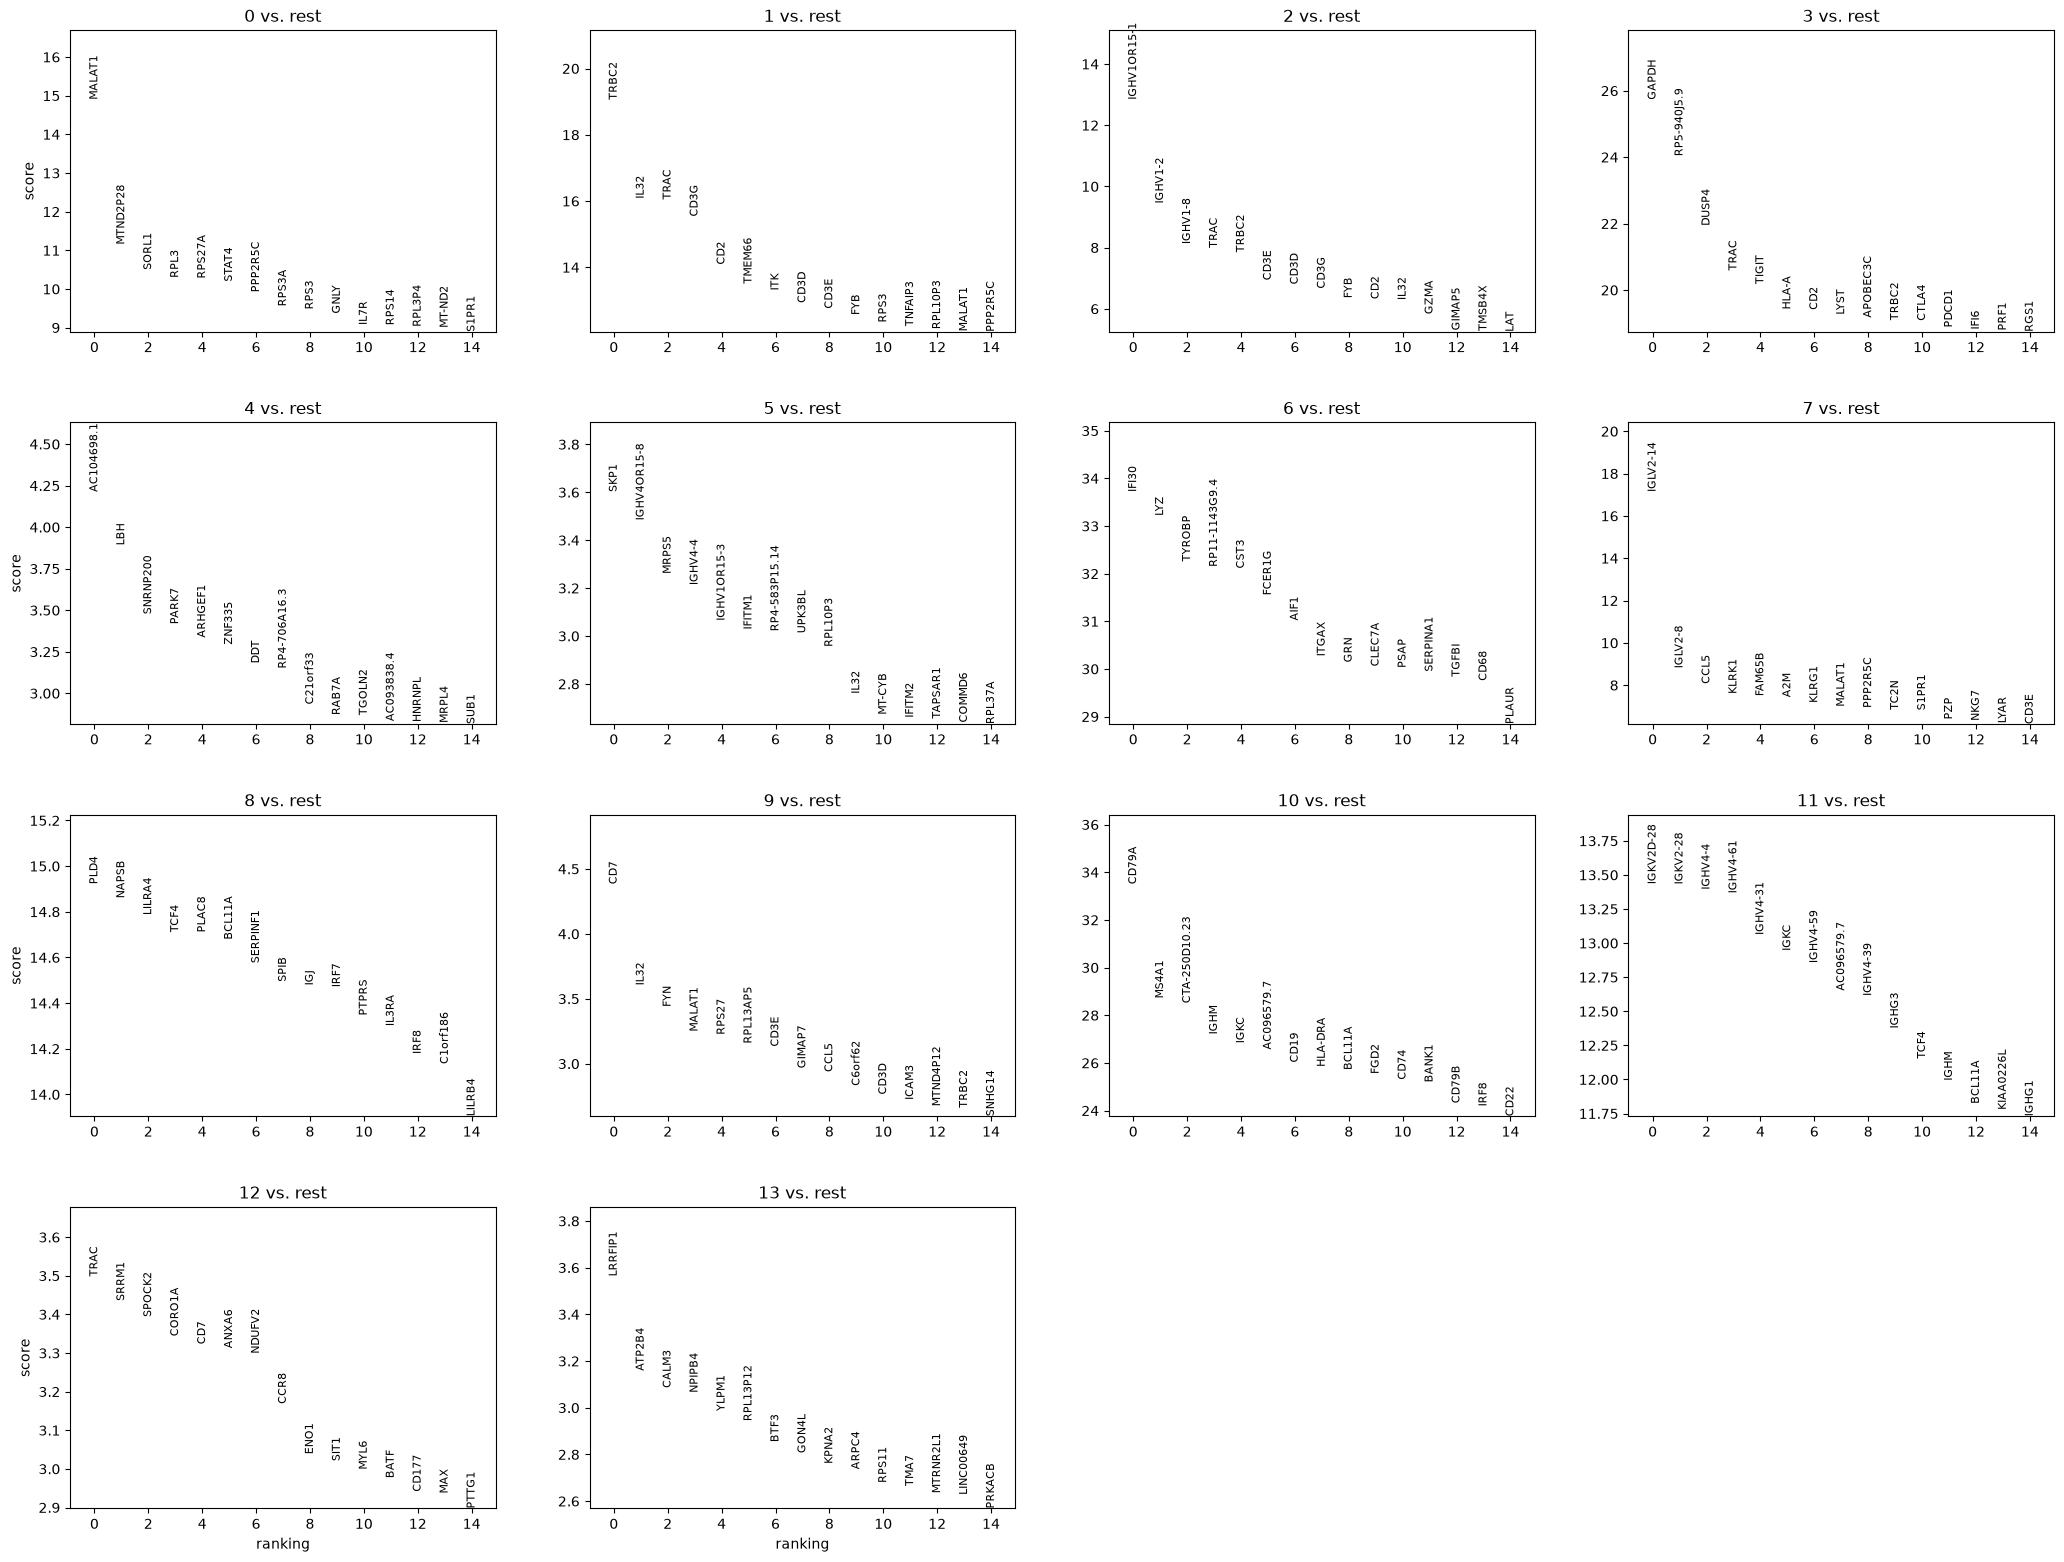

In [ ]:
#finding each clusters gene marker 
#cluster 11 is an immunoglobulin - therefore we do not need to remove it because its not a specific cell specialisation, just antibodies from B cells.
 

sc.tl.rank_genes_groups(adata, "leiden_0.4", method="wilcoxon")

sc.pl.rank_genes_groups(adata, n_genes=15, sharey=False)

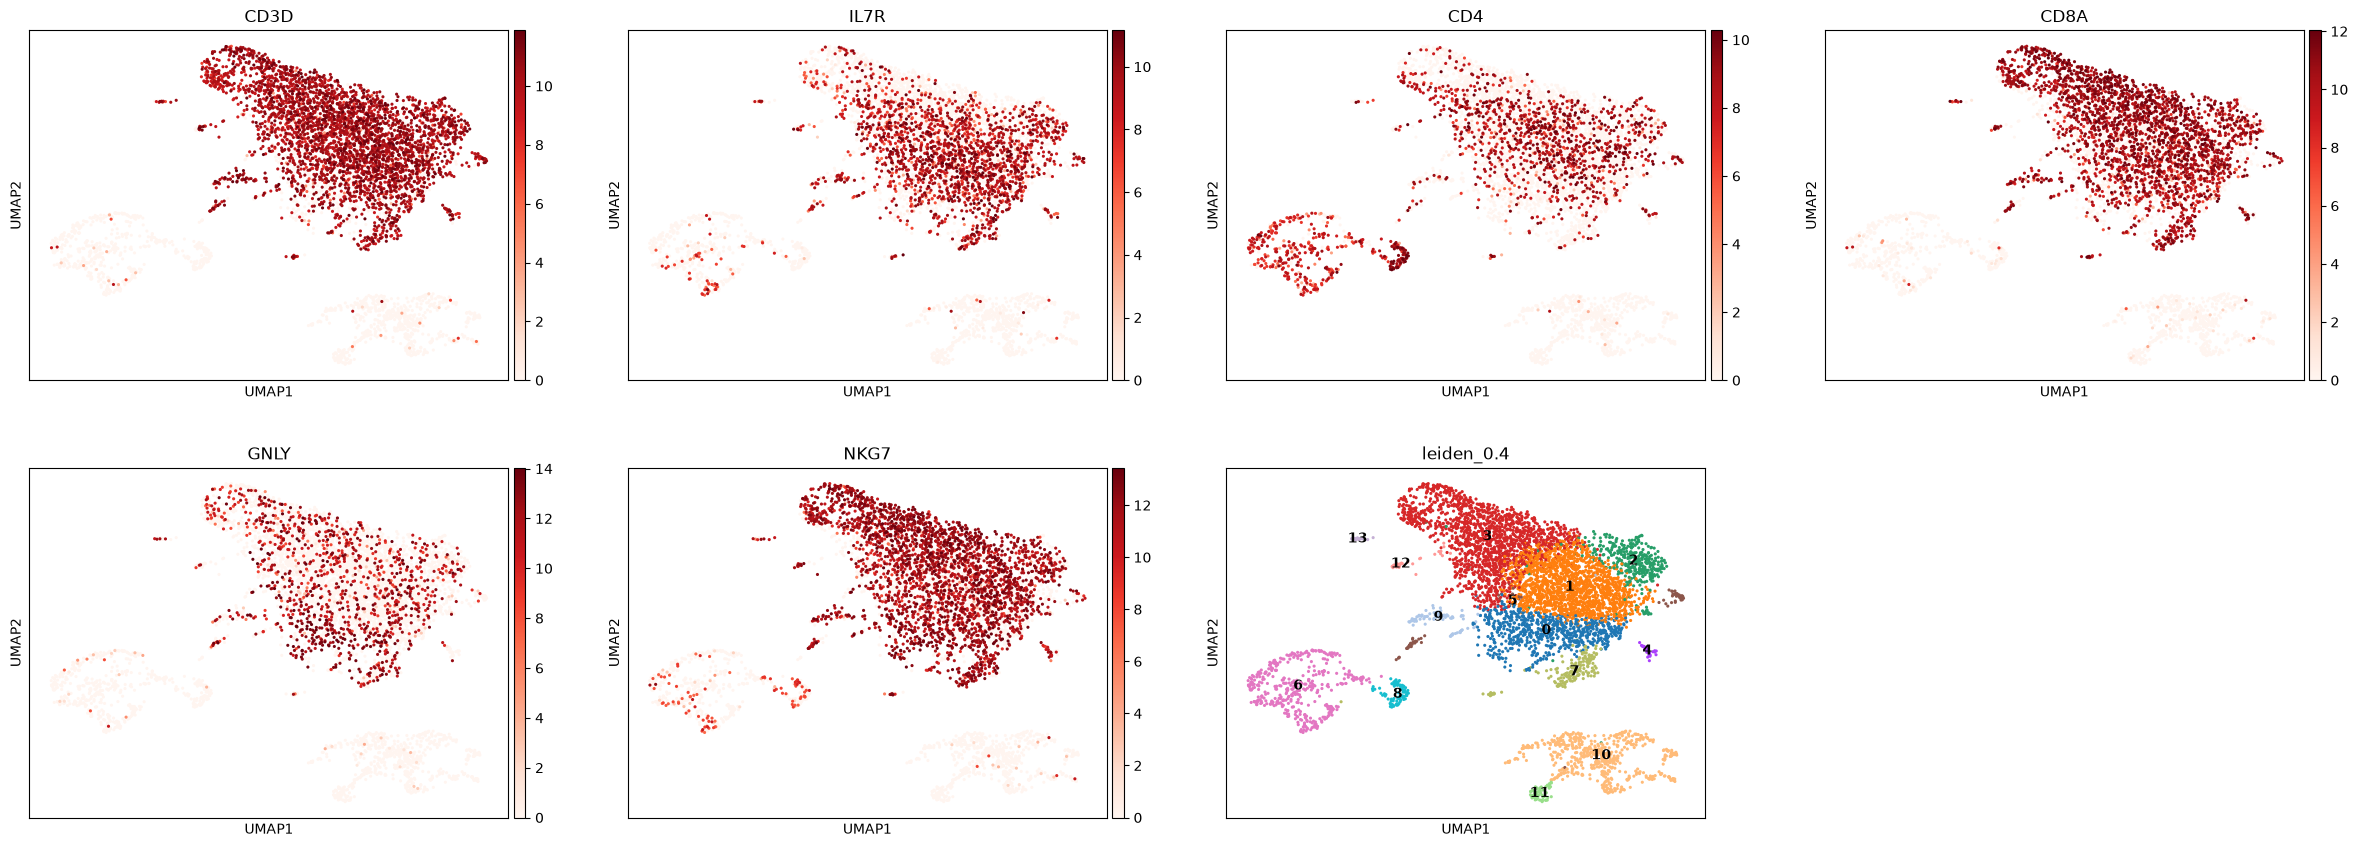

In [ ]:
#cluster 0 points towards naive or memeory T-cell population becuase of IL7R and S1PR1 expression
#but there is also a small population of NK cells in this cluster because of NKG7 and GNLY expression.

#this is code that claude gave that should test this hypothesis. 

#CD3D - the entire central mass is dark red, including cluster 0. 
#Both islands are white so everything in the main mass is T cell, and the islands are not.

#the GNLY plot is not dense in the main mass so i think it is a red herring

#CD8A - the main mass is dark red, but the islands are white.
#so the islands are not CD8 T cells, but the main mass is.

#in conclusion, i believe cluster 0 is a CD8 T-cell population but its not a pure population


sc.pl.umap(adata, color=["CD3D", "IL7R", "CD4", "CD8A", "GNLY", "NKG7", "leiden_0.4"],
           use_raw=True, cmap="Reds", vmax="p99", legend_loc="on data")

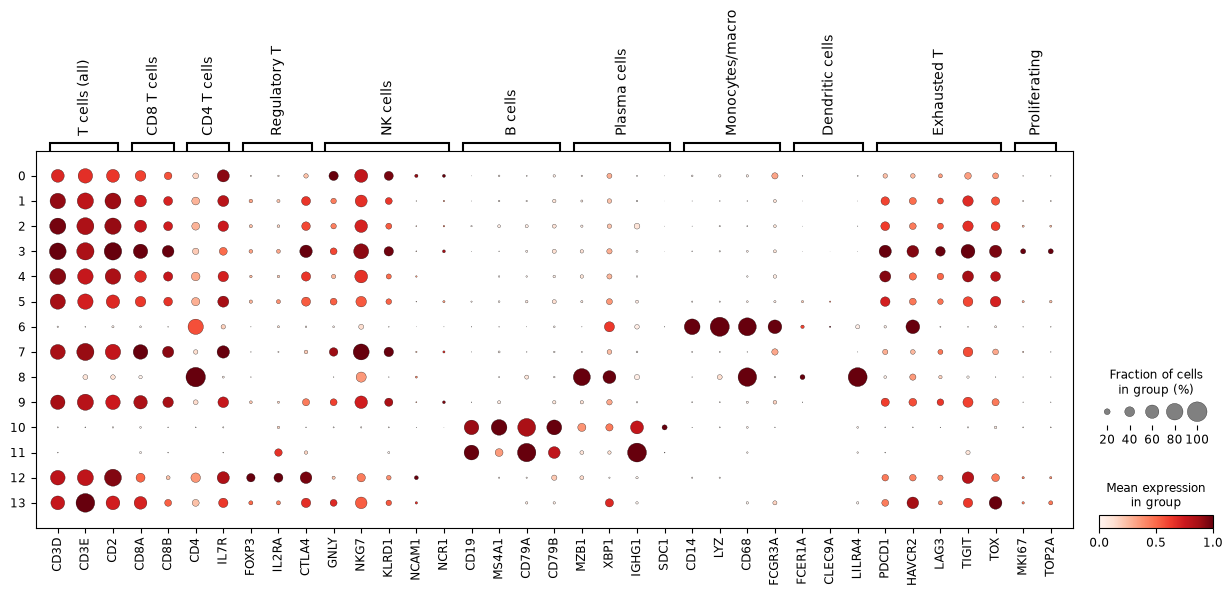

In [ ]:
#cluster 1 is likely a T-cell, either CD4 or CD8, 
#but not NK cells because of the lack of GNLY and NKG7 expression.

#claude recommended a dotplot to see if it is CD4 or CD8 T-cells.
#this is like what was done in chapter 13 of the single cell textbook, but with a different set of genes.


marker_genes = {
    "T cells (all)":      ["CD3D", "CD3E", "CD2"],
    "CD8 T cells":        ["CD8A", "CD8B"],
    "CD4 T cells":        ["CD4", "IL7R"],
    "Regulatory T":       ["FOXP3", "IL2RA", "CTLA4"],
    "NK cells":           ["GNLY", "NKG7", "KLRD1", "NCAM1", "NCR1"],
    "B cells":            ["CD19", "MS4A1", "CD79A", "CD79B"],
    "Plasma cells":       ["MZB1", "XBP1", "IGHG1", "SDC1"],
    "Monocytes/macro":    ["CD14", "LYZ", "CD68", "FCGR3A"],
    "Dendritic cells":    ["FCER1A", "CLEC9A", "LILRA4"],
    "Exhausted T":        ["PDCD1", "HAVCR2", "LAG3", "TIGIT", "TOX"],
    "Proliferating":      ["MKI67", "TOP2A"],
}

marker_genes_in_data = {
    ct: [g for g in genes if g in adata.raw.var_names]
    for ct, genes in marker_genes.items()
}
marker_genes_in_data

sc.pl.dotplot(adata, marker_genes_in_data, groupby="leiden_0.4",
              standard_scale="var", use_raw=True)

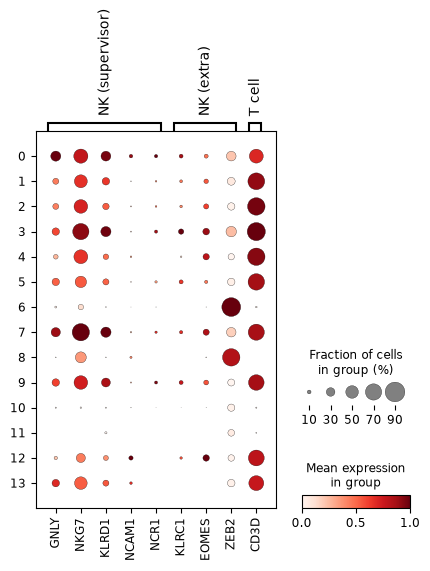

In [ ]:
#these are broad markers that PhD student gave me from the lab 

BROAD_MARKERS = {
    "T cell":               ["CD3D", "CD3E", "CD3G", "CD4", "CD8A", "CD8B", "KLRB1", "ZBTB16"],
    "B cell":               ["CD79A", "CD19", "MS4A1", "JCHAIN", "CD38", "MZB1"],
    "NK cell":              ["KLRD1", "KLRC1", "NCAM1", "EOMES", "ZEB2", "IL7R", "ID2", "AREG"],
    "Monocyte/Macrophage":  ["CD68", "LYZ", "CD14"],
    "cDC":                  ["CLEC9A", "FCER1A", "LAMP3"],
    "pDC":                  ["LILRA4", "IL3RA", "PLD4"],
    "Granulocyte":          ["ITGAM", "CEACAM8", "FUT4", "ANPEP", "TPSAB1"],
    "Progenitor/HSC":       ["CD34", "KIT", "SPINK2", "MKI67", "TOP2A"],
}

# this make another dotplot 

nk_check = {
    "NK (supervisor)": ["GNLY", "NKG7", "KLRD1", "NCAM1", "NCR1"],
    "NK (extra)":      ["KLRC1", "EOMES", "ZEB2"],
    "T cell":          ["CD3D"],
}
nk_check = {k: [g for g in v if g in adata.raw.var_names] for k, v in nk_check.items()}

sc.pl.dotplot(adata, nk_check, groupby="leiden_0.4",
              standard_scale="var", use_raw=True)


#i don't like the way this came out so much but i will keep it in mind for the future.

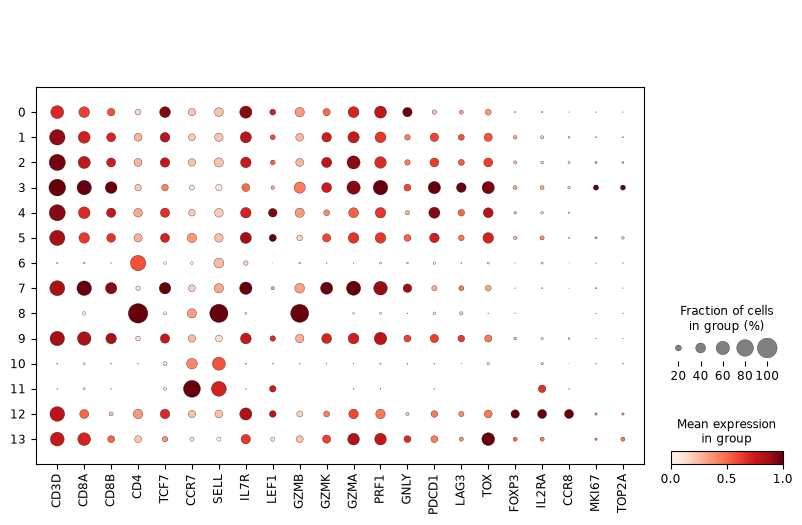

In [ ]:
#one more dotplot to see if we can find the T-cell subtypes in the clusters.
#so far i have 5 solid clusters and im trying to figure out the rest.

t_state = ["CD3D", "CD8A", "CD8B", "CD4",
           "TCF7", "CCR7", "SELL", "IL7R", "LEF1",      # naive / memory / stem-like
           "GZMB", "GZMK", "GZMA", "PRF1", "GNLY",       # cytotoxic / effector
           "PDCD1", "LAG3", "TOX",                        # exhausted
           "FOXP3", "IL2RA", "CCR8",                      # Treg
           "MKI67", "TOP2A"]                              # proliferating
t_state = [g for g in t_state if g in adata.raw.var_names]

sc.pl.dotplot(adata, t_state, groupby="leiden_0.4",
              standard_scale="var", use_raw=True)

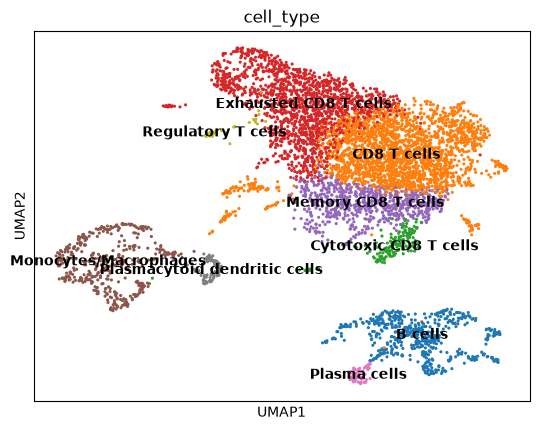

In [ ]:
#this is my mapping so far. 
#this is a prediction and i will need to confirm it with CellTypist 

mapping = {
    "0":  "Memory CD8 T cells",
    "1":  "CD8 T cells",
    "2":  "CD8 T cells",
    "3":  "Exhausted CD8 T cells",
    "4":  "CD8 T cells",
    "5":  "CD8 T cells",
    "6":  "Monocytes/Macrophages",
    "7":  "Cytotoxic CD8 T cells",
    "8":  "Plasmacytoid dendritic cells",
    "9":  "CD8 T cells",
    "10": "B cells",
    "11": "Plasma cells",
    "12": "Regulatory T cells",
    "13": "Exhausted CD8 T cells",
}

adata.obs["cell_type"] = adata.obs["leiden_0.4"].map(mapping).astype("category")
sc.pl.umap(adata, color="cell_type", legend_loc="on data")


#0 — TCF7, IL7R, SELL (memory triad), low exhaustion
#1, 2, 4, 5, 9 — CD3D/CD3E/CD2 + CD8A; no distinguishing state marker → broad label, deliberately
#3 — PDCD1, LAG3, TOX + GZMK/PRF1 + MKI67
#6 — CD14, LYZ, CD68, FCGR3A; CD3D-negative
#7 — GZMB, GZMK, GZMA, PRF1, GNLY; TCF7/SELL low
#8 — LILRA4, PLD4, IL3RA; CD3D-negative
#10 — CD19, MS4A1, CD79A/B
#11 — MZB1, XBP1, IGHG1 + IGKV/IGHV variable genes; 98% one patient = clonal expansion, real biology
#12 — CCR8, IL2RA, FOXP3
#13 — TOX, PRF1; small

In [17]:
#i am checking how many cells there are per label 

adata.obs["cell_type"].value_counts()

cell_type
CD8 T cells                     2290
Exhausted CD8 T cells           1588
Memory CD8 T cells               702
B cells                          574
Monocytes/Macrophages            429
Cytotoxic CD8 T cells            166
Plasmacytoid dendritic cells      82
Plasma cells                      61
Regulatory T cells                34
Name: count, dtype: int64